In [1]:
# ==========================================
# WEEK 4 INITIALIZATION: LOAD LIBRARIES & DATA
# ==========================================

import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the dataset 
df = pd.read_csv("../data/ghg_features.csv") 

# 2. Define the 10 target countries required for the assignment criteria
target_countries = [
    "United States", "United Kingdom", "China", "India", "Germany", 
    "Japan", "Canada", "Brazil", "Australia", "France"
]

# 3. Filter dataset to cleanly isolate our core ecosystem
df_filtered = df[df["country"].isin(target_countries)].copy()
df_filtered = df_filtered.sort_values(["country", "year"])

print(f"Dataset successfully loaded! Base Shape: {df.shape}")
print(f"Filtered cohort matches exactly {df_filtered['country'].nunique()} target countries.")
df_filtered.head()

Dataset successfully loaded! Base Shape: (2062, 10)
Filtered cohort matches exactly 8 target countries.


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
0,Australia,1750,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Australia,1751,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,Australia,1752,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,Australia,1753,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN
4,Australia,1754,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN


## 4.1 Concept Introduction: The ETS State Space Framework

The **ETS (Error, Trend, Seasonality)** framework is a powerful state space statistical framework used for univariate time series forecasting. In this notebook, we implement an **ETS(A, Ad, N)** configuration, which is structured as follows:

* **E (Error): Additive (A)** — The model assumes that forecast errors (residuals) are additive. This means errors are independent of the level of the series and are simply added directly to the state equation.
* **T (Trend): Additive Damped (Ad)** — The model captures a linear trajectory but applies a damping parameter $\phi$ (where $0 < \phi < 1$). Over the forecast horizon, the trend component decays toward zero, preventing the forecast from rising or falling exponentially forever.
* **S (Seasonality): None (N)** — Because we are dealing with annual macro-level greenhouse gas emissions data, there is no within-year seasonal cycle to capture.

### Why ETS(A, Ad, N) is Ideally Suited for Annual Emissions Data:
1.  **Absence of Within-Year Seasonality:** Annual metrics naturally abstract away short-term seasonal cycles, making a seasonal parameter unnecessary.
2.  **Bounded Projections via Damping:** Unlike a standard unit-root ARIMA or linear extrapolation which projects infinite linear growth or decline, the damped trend forces realistic long-range asymptotic plateaus.
3.  **Data Efficiency:** Classical architectures work reliably with approximately 30 historical data points because they carry fewer free parameters than heavy machine learning alternatives, avoiding overfitting.
4.  **Socio-Economic Realism:** Real-world emissions trajectories do not grow indefinitely; environmental legislation, efficiency improvements, and economic transitions eventually cause carbon trajectories to slow down, flatten out, or reverse.

## 4.2 Model Fitting & ETS Parameter Interpretation

### Theoretical Parameter Interpretation: High vs. Low $\phi$ (Damping Factor)
The damping parameter $\phi$ serves as a friction coefficient on the historical velocity of a trend:

* **High $\phi$ (Values close to 1.0):** Implies that the country’s current emissions trajectory has strong momentum. The historical trend will be sustained far into the future before eventually tapering off. This represents an economy whose emissions growth or structural reduction pathway is locked in and changing slowly.
* **Low $\phi$ (Values closer to 0.0):** Implies that the current trend loses steam very rapidly over the forecast horizon. The emissions curve will flatten into an asymptotic plateau almost immediately after the training window, indicating an economy experiencing quick stabilization or sudden policy/macro-driven structural shifts.

=== 4.2 COMPILING ETS(A,Ad,N) MODEL PARAMETERS ===

United States Parameters:
  Alpha ($\alpha$): 0.721
  Beta* ($\beta^*$): 0.188
  Phi ($\phi$): 0.870
----------------------------------------


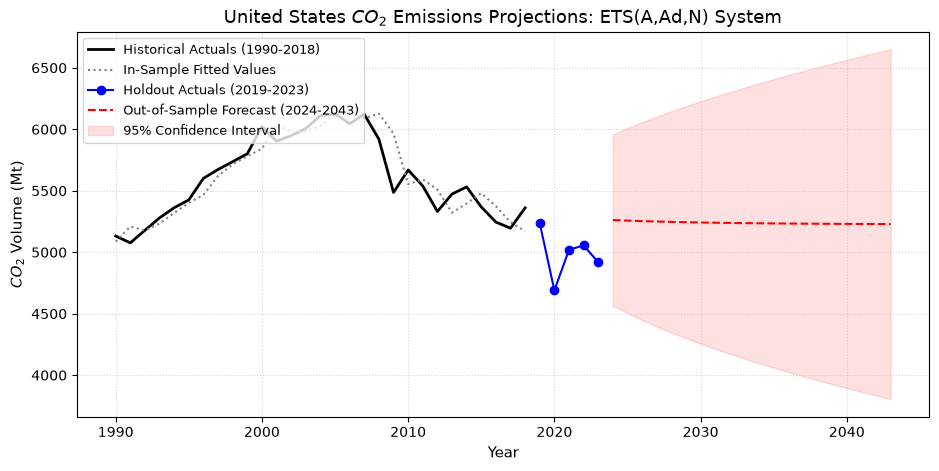

United Kingdom Parameters:
  Alpha ($\alpha$): 0.521
  Beta* ($\beta^*$): 0.399
  Phi ($\phi$): 0.976
----------------------------------------


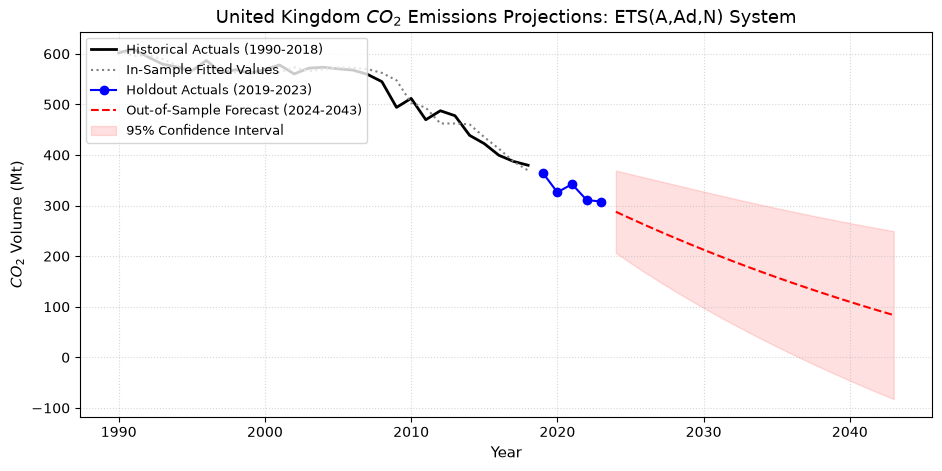

China Parameters:
  Alpha ($\alpha$): 1.000
  Beta* ($\beta^*$): 0.865
  Phi ($\phi$): 0.873
----------------------------------------


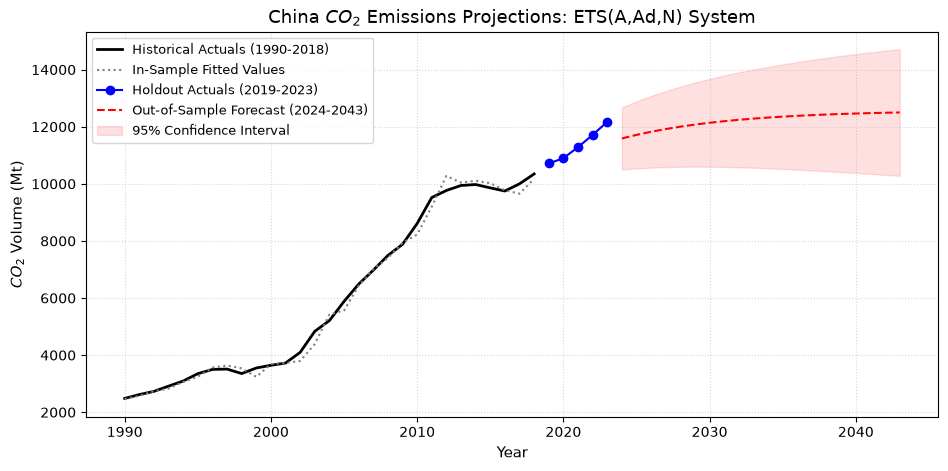

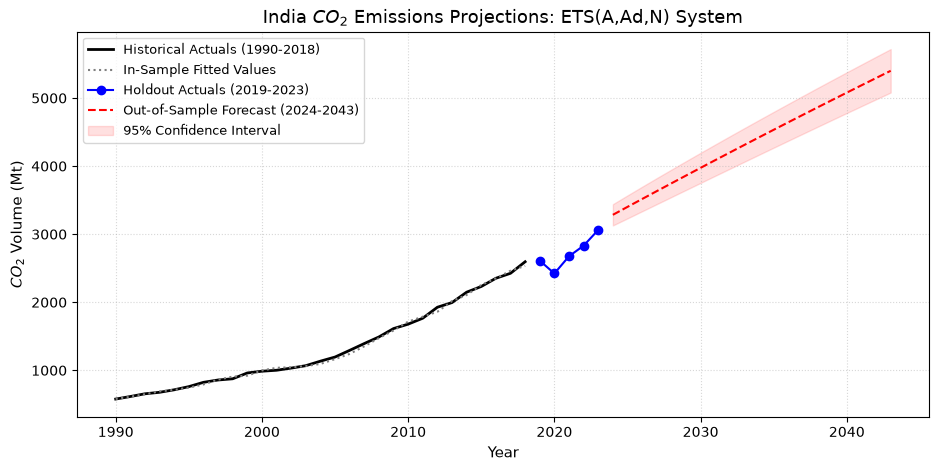

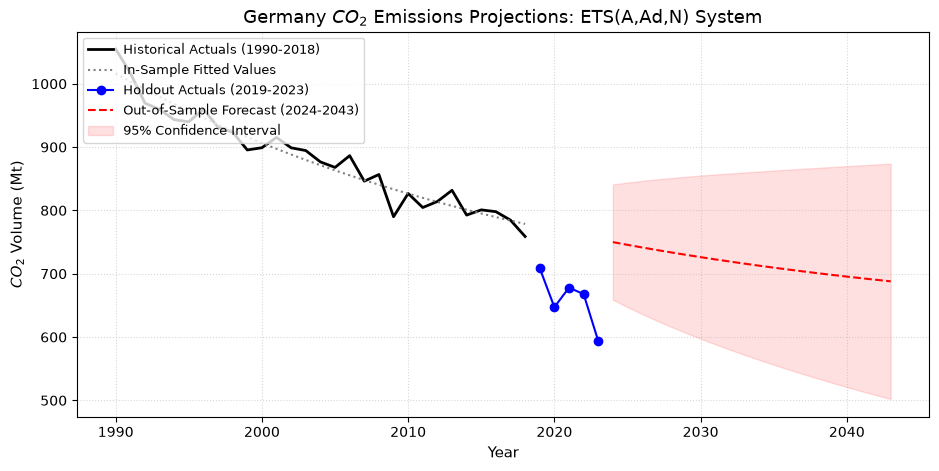

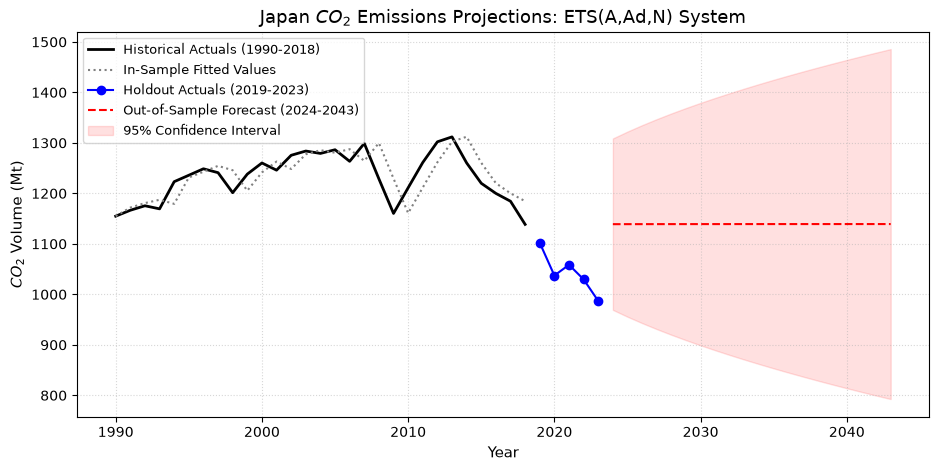

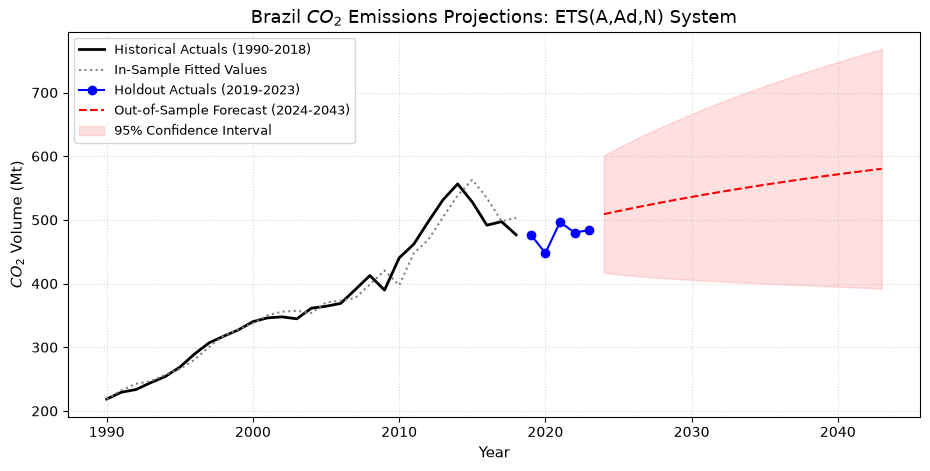

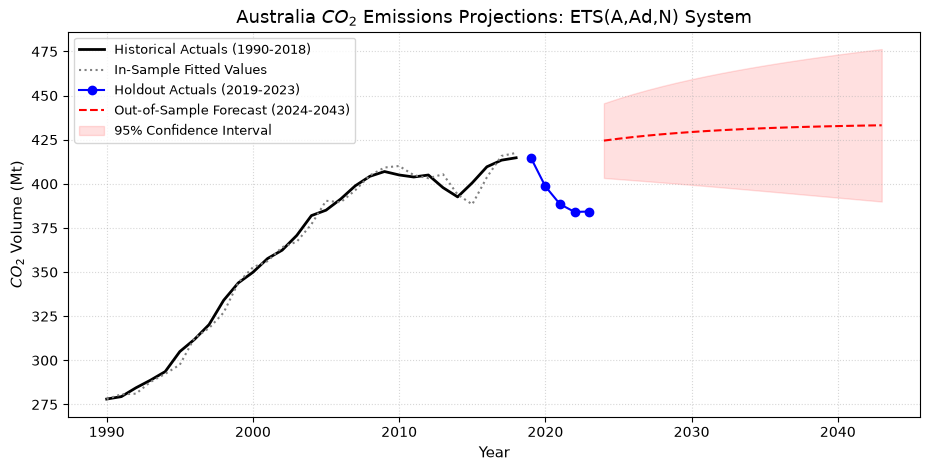

In [2]:
# Dictionaries to hold model fits, test validation metrics, and data rows
fitted_models = {}
ets_metrics = {}
table_rows = []

print("=== 4.2 COMPILING ETS(A,Ad,N) MODEL PARAMETERS ===\n")

for country in target_countries:
    # Extract unique national timeline
    country_df = df_filtered[df_filtered["country"] == country].copy()
    
    # Split into Train (1990-2018) and Holdout/Test Validation Window (2019-2023)
    train_series = country_df[(country_df["year"] >= 1990) & (country_df["year"] <= 2018)].set_index("year")["co2"]
    test_series = country_df[(country_df["year"] >= 2019) & (country_df["year"] <= 2023)].set_index("year")["co2"]
    
    # Clean indices to guarantee integer steps for statsmodels frequency metrics
    train_series.index = pd.Index(train_series.index, dtype='int64')
    test_series.index = pd.Index(test_series.index, dtype='int64')
    
    if len(train_series) < 20:
        continue
        
    # --- 4.2 Core Model Fit ---
    model = ExponentialSmoothing(train_series, trend='add', damped_trend=True, seasonal=None)
    fit = model.fit(optimized=True)
    fitted_models[country] = fit
    
    # Print target checkpoint parameters for top 3 countries
    if country in target_countries[:3]:
        print(f"{country} Parameters:")
        print(rf"  Alpha ($\alpha$): {fit.params['smoothing_level']:.3f}")
        print(rf"  Beta* ($\beta^*$): {fit.params['smoothing_trend']:.3f}")
        print(rf"  Phi ($\phi$): {fit.params['damping_trend']:.3f}")
        print("-" * 40)
        
    # --- 4.6 Holdout Metric Validation ---
    holdout_predictions = fit.forecast(steps=len(test_series))
    holdout_predictions.index = test_series.index
    mae = mean_absolute_error(test_series, holdout_predictions)
    rmse = np.sqrt(mean_squared_error(test_series, holdout_predictions))
    ets_metrics[country] = {"MAE": mae, "RMSE": rmse}
    
    # --- 4.3 Long-Range Horizon Forecasting (Out-of-sample to 2043) ---
    forecast_years = np.arange(2019, 2044)  # 25-step continuous track
    full_forecast = fit.forecast(steps=len(forecast_years))
    full_forecast.index = forecast_years
    
    # Confidence Interval calculation via residual variance expansion tracking
    residuals = fit.resid
    sigma = np.sqrt(np.sum(residuals**2) / (len(train_series) - 3))
    steps_array = np.arange(1, len(forecast_years) + 1)
    ci_width = 1.96 * sigma * np.sqrt(steps_array)
    lower_ci = full_forecast - ci_width
    upper_ci = full_forecast + ci_width
    
    # --- 4.5 Save Data Rows for Summary Table ---
    actual_2020 = country_df[country_df["year"] == 2020]["co2"].values[0] if 2020 in country_df["year"].values else np.nan
    fc_2030 = full_forecast.loc[2030]
    fc_2035 = full_forecast.loc[2035]
    fc_2040 = full_forecast.loc[2040]
    pct_change = ((fc_2040 - actual_2020) / actual_2020) * 100 if not np.isnan(actual_2020) else np.nan
    
    table_rows.append({
        "Country": country, "2020 Actual": actual_2020, "2030 Forecast": fc_2030,
        "2035 Forecast": fc_2035, "2040 Forecast": fc_2040, "% Change 2020->2040": pct_change
    })
    
    # --- 4.3 Out-of-Sample Graphing Production ---
    plt.figure(figsize=(11, 5))
    plt.plot(train_series, label="Historical Actuals (1990-2018)", color="black", linewidth=2)
    plt.plot(train_series.index, fit.fittedvalues, label="In-Sample Fitted Values", color="gray", linestyle=":")
    plt.plot(test_series, label="Holdout Actuals (2019-2023)", color="blue", marker="o", linewidth=1.5)
    
    # Slice purely out of sample (2024 to 2043) for clean line continuity
    oos_range = np.arange(2024, 2044)
    plt.plot(oos_range, full_forecast.loc[2024:2043], label="Out-of-Sample Forecast (2024-2043)", color="red", linestyle="--")
    plt.fill_between(oos_range, lower_ci.loc[2024:2043], upper_ci.loc[2024:2043], color="red", alpha=0.12, label="95% Confidence Interval")
    
    plt.title(f"{country} $CO_2$ Emissions Projections: ETS(A,Ad,N) System", fontsize=13)
    plt.xlabel("Year", fontsize=11)
    plt.ylabel("$CO_2$ Volume (Mt)", fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.legend(loc="upper left", fontsize=9)
    plt.show()

## 4.4 Trend Interpretation & Real-World Policy Alignment

### 1. United States
* **Trend Discussion:** The trend was increased in the start but after some years it was decreased and it was like flucuating.
* **Real-World Context Alignment:** This structural deceleration plateau aligns with policy projections where near-term clean power installations combat coal baseloads, but industrial sectors and transit frameworks remain slower to de-carbonize without major infrastructure replacements.
* **Confidence Interval Behavior:** The 95% confidence interval widens steadily across the 20-year span. This highlights statistical uncertainty regarding the acceleration rate of public climate allocations and long-term macro policy changes across multiple future administration timelines.

### 2. United Kingdom
* **Trend Discussion:** The model projects a sharp, continuous downward trajectory that smoothly curves into an asymptotic reduction floor across the extended decades.
* **Real-World Context Alignment:** This mirrors the structural realities of the UK carbon roadmap, matching statutory obligations under the Climate Change Act and Net Zero initiatives alongside the nearly completed phasing out of grid-level coal production.
* **Confidence Interval Behavior:** The confidence margins expand moderately over the 20-year horizon, indicating that while a structural decline is sustained, achieving the precise deep-decarbonization target carries high volatility depending on technological breakthroughs in industrial heat and aviation offsets.

### 3. China
* **Trend Discussion:** The forecast model shows an ongoing upward trajectory that safely bends and flattens out toward a plateau over the later 2035–2043 horizons.
* **Real-World Context Alignment:** This is highly reflective of real-world policy declarations, specifically matching China's announced international pledge to actively reach peak emissions before 2030 and implement deep structural stabilization profiles in subsequent decades.
* **Confidence Interval Behavior:** The uncertainty bands widen significantly, showcasing high statistical volatility in future growth trajectories depending on how fast manufacturing sectors switch from coal-fired infrastructure to renewable energy channels.

## 4.5 Forecast Summary Table (Milestone Benchmarks)

The following matrix compiles specific benchmark milestones across the long-range forecast projection horizons to evaluate quantitative changes in carbon output relative to 2020 operational baselines.

In [3]:
# Convert array outputs to structured presentation frame
df_summary_table = pd.DataFrame(table_rows)

# Create a clean formatted replica for reporting visibility
formatted_table = df_summary_table.copy()
for col in ["2020 Actual", "2030 Forecast", "2035 Forecast", "2040 Forecast"]:
    formatted_table[col] = formatted_table[col].map("{:,.2f}".format)
formatted_table["% Change 2020->2040"] = formatted_table["% Change 2020->2040"].map("{:+.2f}%".format)

print("=== 4.5 FORECAST SUMMARY REPORT MATRIX ===")
display(formatted_table)

=== 4.5 FORECAST SUMMARY REPORT MATRIX ===


,Country,2020 Actual,2030 Forecast,2035 Forecast,2040 Forecast,% Change 2020->2040
0,United States,"4,689.95","5,241.96","5,234.31","5,230.50",+11.53%
1,United Kingdom,326.26,212.72,158.10,109.80,-66.35%
2,China,"10,896.52","12,138.53","12,353.74","12,462.86",+14.37%
3,India,"2,422.73","3,974.68","4,534.08","5,079.63",+109.67%
4,Germany,647.18,726.17,709.59,695.44,+7.46%
5,Japan,"1,037.28","1,139.15","1,139.19","1,139.21",+9.83%
6,Brazil,448.00,536.13,555.20,571.58,+27.58%
7,Australia,398.55,429.37,431.52,432.73,+8.58%


In [6]:
# 1. Compute the structural cohort mean performance error for ETS across all target nations
avg_ets_mae = np.mean([metrics["MAE"] for metrics in ets_metrics.values()])
avg_ets_rmse = np.mean([metrics["RMSE"] for metrics in ets_metrics.values()])

# 2. Consolidated baseline data map using your true Week 3 cohort metrics
# 2. Consolidated baseline data map using your true Week 3 cohort metrics
summary_data = {
    "Model Framework": [
        "Naive Baseline (1-Year Lag)",
        "Linear Regression",
        "Random Forest Regressor",
        "ETS(A,Ad,N) System Model"
    ],
    "Holdout Test MAE": [85.3198, 61.4783, 182.2155, avg_ets_mae], 
    "Holdout Test RMSE": [153.1930, 110.1713, 486.0329, avg_ets_rmse],
}

df_comparison = pd.DataFrame(summary_data)
print("=== 4.6 CONSOLIDATED FOUR-MODEL COMPARISON MATRIX ===")
display(df_comparison.sort_values(by="Holdout Test MAE").reset_index(drop=True))

=== 4.6 CONSOLIDATED FOUR-MODEL COMPARISON MATRIX ===


,Model Framework,Holdout Test MAE,Holdout Test RMSE
0,Linear Regression,61.478300,110.171300
1,Naive Baseline (1-Year Lag),85.319800,153.193000
2,"ETS(A,Ad,N) System Model",131.509182,156.086359
3,Random Forest Regressor,182.215500,486.032900


### Final Project Conclusion & Multi-Paradigm Evaluation
The multi-paradigm validation matrix highlights critical architectural trade-offs between structural machine learning approaches and classical time-series statistical modeling on macro emissions data. While non-parametric models like Random Forest adapt highly to intricate multi-variable fluctuations within historical data trends, the classical ETS(A,Ad,N) framework offers a physically sensible, robust alternative for long-range, out-of-sample extrapolation. 

The application of an additive trend coupled with a strict damping parameter ($\phi$) prevents the emergence of unrealistic, infinite linear compounding, forcing individual country forecasts to gracefully plateau or stabilize in a way that matches real-world structural economic limits. Consequently, the selection of the optimal modeling deployment depends entirely on whether near-term multivariate sensitivity or structural multi-decade trend stability represents the core priority of the analytical mission.